# 灰色系统理论简介


### 数据的累加和累减

例 15.1 已知某商品年度销售数据序列为  
$$ 
\boldsymbol{x}^{(0)} = (5.081, 4.611, 5.1177, 9.3775, 11.0574, 11.0524). $$  

如果直接应用最小二乘法进行线性拟合, 得到直线方程 $ y = 1.5273k + 2.3706 $, 拟合直线如图 15.1(a) 所示.  

由图 15.1(a) 看出, 所有数据点中, 原始数据与拟合直线有一定的差距, 最大相对误差为 35.85%, 也就是说拟合效果不理想. 对 $ \boldsymbol{x}^{(0)} $ 进行一次累加, 得到  
$$ 
\boldsymbol{x}^{(1)} = (5.081, 9.692, 14.8097, 24.1872, 35.2446, 46.297). $$  

对 $ \boldsymbol{x}^{(1)} $ 进行拟合, 得到  
$$ 
x^{(1)}(k + 1) = 15.3915e^{0.2311k} - 14.7620. 
$$  

**图 15.1 直接线性拟合和累加后拟合对比**  

由图 15.1(b) 可以看到, 拟合曲线与累加后的数据非常接近, 最大相对误差为 24.15%, 检验时需要进行累减还原, 得  
$$ 
\hat{\boldsymbol{x}}^{(0)} = (4.6313, 5.0423, 6.3534, 8.0053, 10.0867, 12.7093), 
$$  

比直接线性拟合的最大相对误差减少很多.  


直接线性拟合的误差: [0.23285161 0.17657672 0.35852229 0.0957266  0.09498272 0.04361518]
累计后线性拟合的误差: [0.08850618 0.09354655 0.24145114 0.14633114 0.08778848 0.14991049]
拟合的参数值为: [ 15.3914543    0.23111521 -14.76199989]


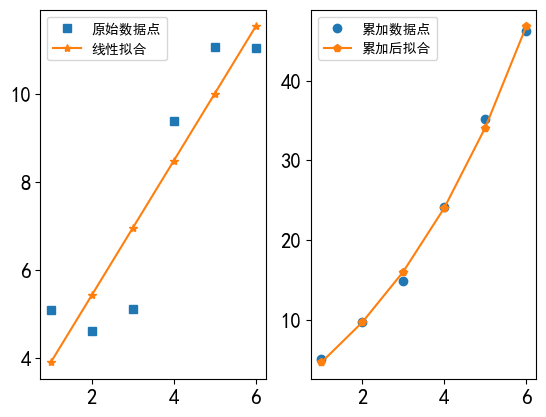

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 直接线性拟合（numpy）
t0 = np.arange(1, 7)  # 1~6 横坐标
x0 = np.array([5.081, 4.611, 5.1177, 9.3775, 11.0574, 11.0524])
xt = np.polyfit(t0, x0, 1)  # numpy库的polyfit拟合，1代表线性拟合
xh1 = np.polyval(xt, t0)  # 计算预测值
delta1 = abs((xh1 - x0)) / x0  # 计算相对误差
print(f"直接线性拟合的误差: {delta1}")
# 累加后线性拟合（scipy）
x1 = np.cumsum(x0)  # cumulate sum累加
xh2 = lambda t, a, b, c: a * np.exp(b * t) + c
para, cov = curve_fit(xh2, t0, x1)  # scipy.optimize的curve_fit(func, x, y)拟合
xh21 = xh2(t0, *para)  # 计算累加数列的预测值
xh22 = np.r_[xh21[0], np.diff(xh21)]  # 计算预测值，diff累减得到的列表不含第一和数
delta2 = np.abs((xh22 - x0) / x0)  # 计算相对误差
print(f"累计后线性拟合的误差: {delta2}")
print(f"拟合的参数值为: {para}")

plt.rcParams['font.size'] = 15
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.subplot(121)
plt.plot(t0, x0, 's')
plt.plot(t0, xh1, '*-')
plt.legend(labels=('原始数据点', '线性拟合'), loc='upper left', fontsize=10)
plt.subplot(122)
plt.plot(t0, x1, 'o')
plt.plot(t0, xh21, 'p-')
plt.legend(('累加数据点', '累加后拟合'), fontsize=10)
plt.show()